<a href="https://colab.research.google.com/github/aditi-tawade-ai/SkillBuilding/blob/main/ML_Practice/Preprocessing_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Assiggnment: check library missingno
# Plot the NaN present in your dataset

# 3 ways to plot missing values
# missingno library
# bar plot
# heatmap

In [ ]:
# Difference between transform and fit_transform

In [ ]:
# Asisgnment:
#1. Select embarked,class,embark_town and apply Label encoder --> replace these columns with numeric value

In [ ]:
# Interview question:
# What are different ways to deal with Categorical data?
# How to perform encoding in ML?
# How to convert categorical data using pandas
# how to convert categorical data using sklearn.preprocessing

In [ ]:
import pandas as pd
path = '/content/sample.csv'
s = pd.read_csv(path)
s

,0,1,2
0,India,38.0,NaN
1,France,43.0,45000.0
2,Germany,30.0,54000.0
3,France,48.0,65000.0
4,Germany,40.0,NaN
5,India,35.0,58000.0
6,Germany,NaN,53000.0
7,France,49.0,79000.0
8,India,50.0,88000.0
9,France,NaN,77000.0


In [ ]:
# finding missing values
# shows missing no of values in each column
s.isnull().sum()

,0
0,0
1,2
2,2


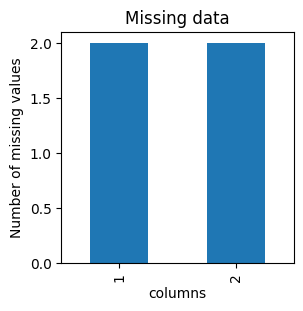

In [ ]:
# 1st way:- barplot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(3,3))
missing = s.isna().sum()
missing = missing[missing>0]
missing.plot(kind='bar')
#plt.figure(figsize=(3,3))
plt.ylabel('Number of missing values')
plt.xlabel('columns')
plt.title('Missing data')
plt.show()

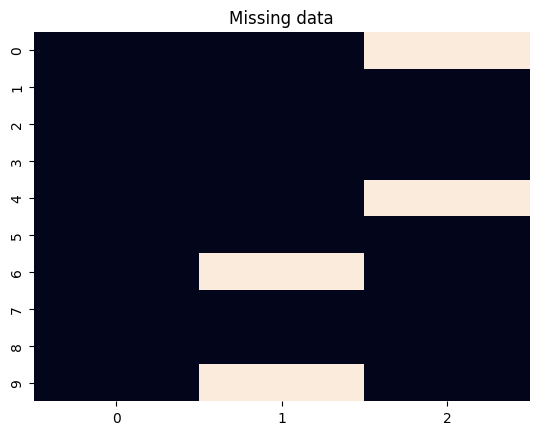

In [ ]:
# method-2 heatmap
sns.heatmap(s.isnull(),cbar=False)
plt.title('Missing data')
plt.show()

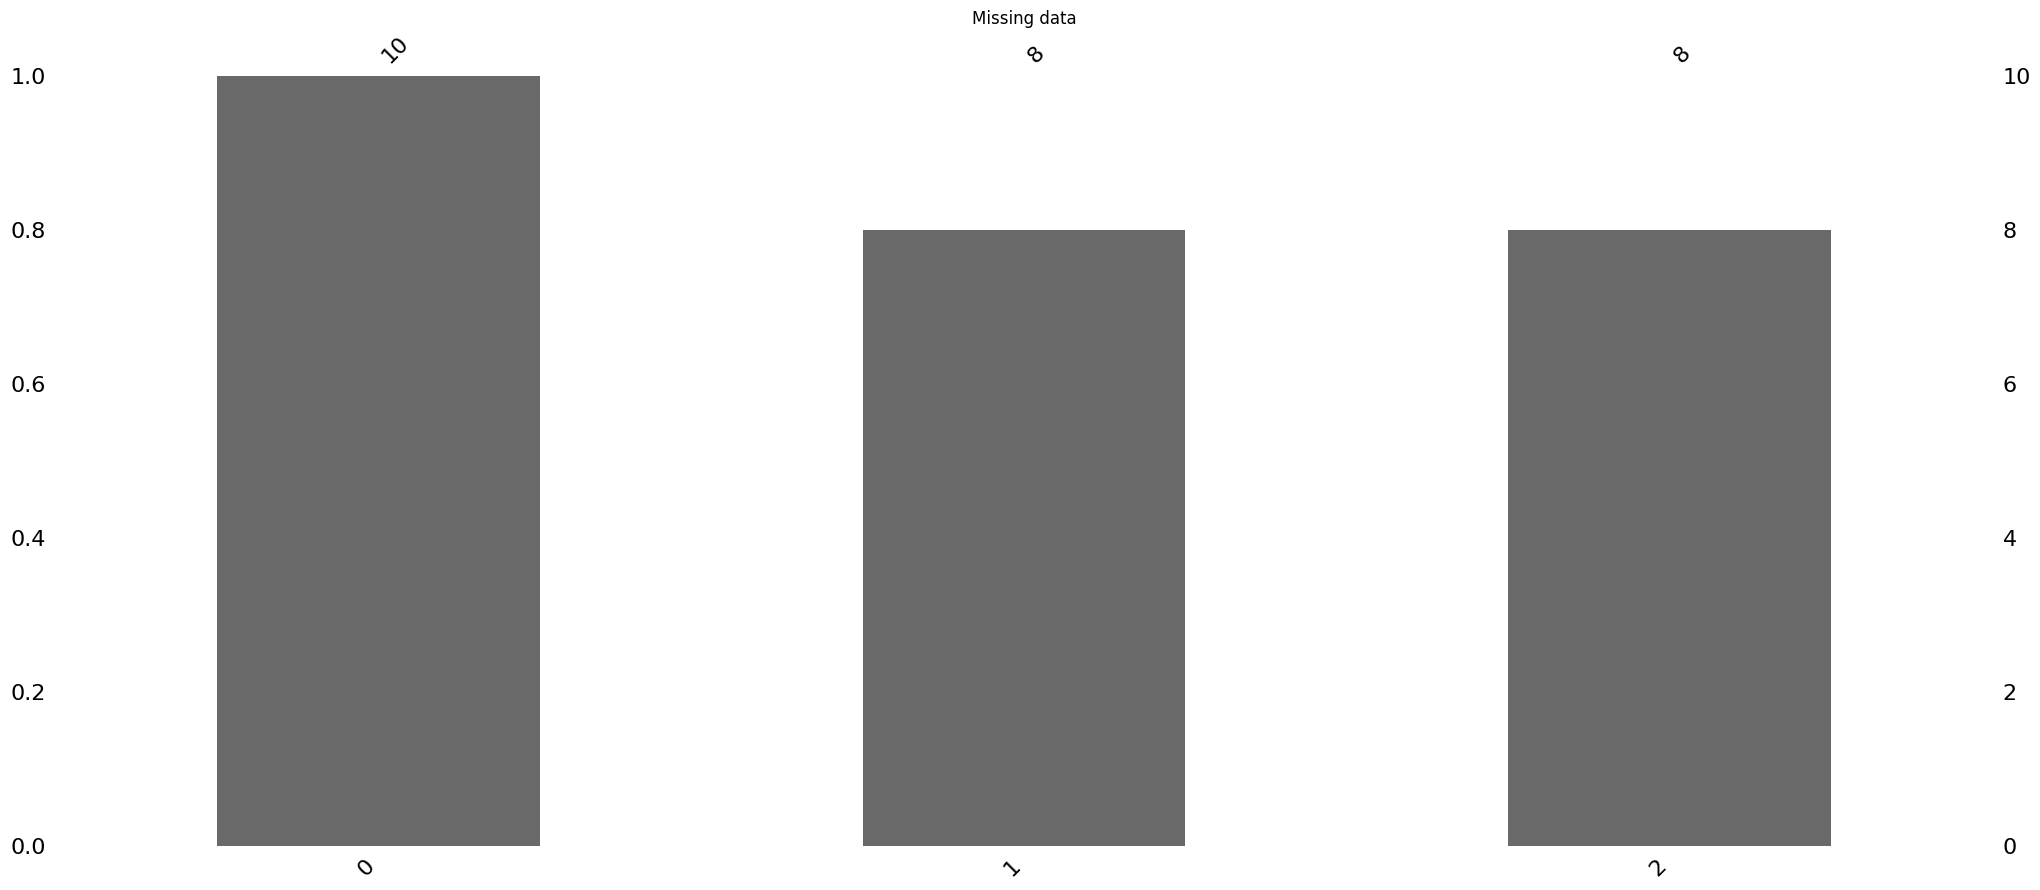

In [ ]:
# method 3: missingno
import missingno as msno
msno.bar(s)
plt.title('Missing data')
plt.show()


From above observation we can compare each method as follows:
- isna().sum(): it tells exact no. of missing values in each column

- sns.heatmap: it showa where exactly the missing value is present inside the column

- msno bar: how much data is present in each column

# Data preprocessing:
- the data available is in raw format which may it containsmissing values,noise which is not accepted in ML

- So data preprocessing is required for cleaning the data and making it suitable for ML model

# Encoding:
- The categorical data present in the dataset is not readable for machine

- So we convert the categorical data in a numerical form as 0,1,2... and this process is called as encoding

- There are 2 wayto deal with categorical data:
1. nominal data- sequence is not necessory
- here we can use map,replace
2. ordinal data - sequence is necessory
- here we use sklearn preprocessing
label encoder

- we have 2 methods here:
i. fit      ii. transform

## Difference between transform and fit_transform:
- Transform is used on test data

- fit_transform is used on train data

In [ ]:
# Asisgnment:
#1. Select embarked,class,embark_town and apply Label encoder --> replace these columns with numeric value

In [ ]:
import seaborn as sns
t = sns.load_dataset('titanic')
t[:2]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [ ]:
t.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
tn = t[['embarked','class','embark_town']]
tn

,embarked,class,embark_town
0,S,Third,Southampton
1,C,First,Cherbourg
2,S,Third,Southampton
3,S,First,Southampton
4,S,Third,Southampton
...,...,...,...
886,S,Second,Southampton
887,S,First,Southampton
888,S,Third,Southampton
889,C,First,Cherbourg


In [ ]:
tn.isna().sum()

,0
embarked,2
class,0
embark_town,2


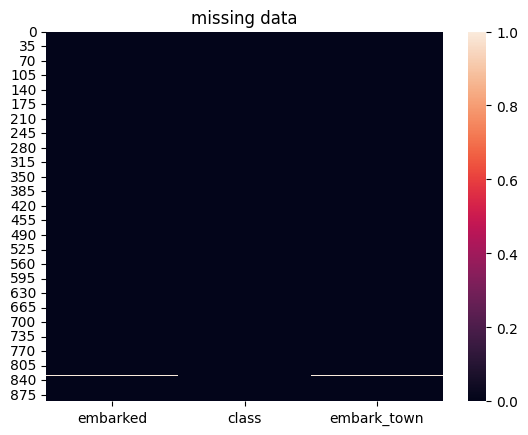

In [ ]:
sns.heatmap(tn.isnull())
plt.title('missing data')
plt.show()

In [ ]:
newt=tn.fillna(method='ffill')
newt

/tmp/ipykernel_1668/1452273783.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  newt=tn.fillna(method='ffill')


,embarked,class,embark_town
0,S,Third,Southampton
1,C,First,Cherbourg
2,S,Third,Southampton
3,S,First,Southampton
4,S,Third,Southampton
...,...,...,...
886,S,Second,Southampton
887,S,First,Southampton
888,S,Third,Southampton
889,C,First,Cherbourg


In [ ]:
newt.isna().sum()

,0
embarked,0
class,0
embark_town,0


In [ ]:
newt['embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [ ]:
newt['class'].unique()

['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']

In [ ]:
newt['embark_town'].unique()

array(['Southampton', 'Cherbourg', 'Queenstown'], dtype=object)

In [ ]:
newt.columns

Index(['embarked', 'class', 'embark_town'], dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
lb.fit(newt['embarked'])


LabelEncoder()

In [ ]:
for col in newt.columns:
  newt['new_'+col]=lb.fit_transform(newt[col])

In [ ]:
newt

,embarked,class,embark_town,new_embarked,new_class,new_embark_town
0,S,Third,Southampton,2,2,2
1,C,First,Cherbourg,0,0,0
2,S,Third,Southampton,2,2,2
3,S,First,Southampton,2,0,2
4,S,Third,Southampton,2,2,2
...,...,...,...,...,...,...
886,S,Second,Southampton,2,1,2
887,S,First,Southampton,2,0,2
888,S,Third,Southampton,2,2,2
889,C,First,Cherbourg,0,0,0
